# **The Win Condition: Exploring the Impact of Magic: The Gathering Card Features on Deck Win Rates**

**Abby Ortego**

**Milestone 1**

**[Github Webpage](https://abbyortego.github.io/cmps-6790-final-tutorial/)**

In [1]:
import requests
from bs4 import BeautifulSoup
import regex as re
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

## Project Goal & Plan

[Magic: The Gathering (MTG)](https://magic.wizards.com/en/intro) is a popular, fantasy-based trading card game with competitive tournaments hosted around the globe. By amassing a vast collection of impressive cards, a player can construct their own custom decks from their collection. During deck construction, players must adhere to a deck size limit while maintaining a balance between the types of interaction and resource cards. This trade-off makes for an interesting analysis into what is most important when constructing a game winning deck. 

This notebook aims to answer the following questions: 
1. Do certain features of a deck correlate with the game outcome? 
2. If so, which features have the biggest impact in determining a winning outcome for a player?  
3. Using those features, can we predict the probability of winning a game from just a deck? 

## Datasets

### Tournaments

The "winability" of a deck is best observed in tournaments which are held around the world, drawing the attention of a variety of players. When a tournament has ended, the host reports participating players, the decks used, tournament outcomes, and more. One site that collects and displays this information is [MTGTop8](https://mtgtop8.com) which sources its data from reliable reporting services (e.g., [Melee](https://melee.gg/), [Magic Events](https://magic.gg/), etc.). However, the site has no public facing API, so it must be scraped. Thankfully, it's [Privacy Policy](https://mtgtop8.com/privacy) and [robots.txt](https://mtgtop8.com/robots.txt) file does not ban web scrapers. 

MTGTop8 offers a lot of data on it's site and not all of it is relevant to predicting deck winability. Due to this, we'll focus on only a subset of tournaments and their features, such as major events played in the standard format within the last full month (March 2026). Restricting our search to only major events allows us to limit the amount of requests we'll need to issue to the site while still collecting a reliably large deck dataset. The standard format for tournaments requires decks to be constructed from cards released within the last 2-3 years, so we can avoid the possibility of more recent decks with newer, fancier abilities overpowering older decks and some aspects of the experience gap that can exist between players. Lastly, analyzing the most recent tournaments will best reflect which current aspects of a deck are most important for winning since these strategies do change over time.

### Decks

While MTGTop8 offers a plethora of tournament data, we'll still need more information if we're going to perform in-depth analysis on the decks used. Specifically, we'll need to have the deck's card data so that we can form descriptive statistics for a deck. [MTGJSON](https://mtgjson.com/) collects data from reliable services, such as Magic: The Gathering's [Gatherer](https://gatherer.wizards.com/) or API's like [Scryfall](https://scryfall.com/docs/api) and [TCGplayer](https://docs.tcgplayer.com/docs/welcome). This data includes in-depth descriptions of MTG cards, such as the name of the card, type of the card, the in-game cost associated with playing the card and more! They package this data into the portable JSON format that can be downloaded from their site.

As discussed above, MTG limits the card sets that can be used to construct decks in standard tournaments to those released roughly within the last year. You can see the current set list and read more [here](https://magic.wizards.com/en/formats/standard). MTGJSON allows us to download each of these sets individually [here](https://mtgjson.com/downloads/all-sets/). The `mtg-sets` directory stores a JSON file for each set listed above named by its abbreviation. When loading in card data, we will be doing so from there. 

# Extracting, Transforming, & Loading Data

## Scraping Tournament Data

### Extracting Tournaments

On this [page](https://mtgtop8.com/format?f=ST&meta=46&a=) under the "Last 20 Events" header, major events played in the standard format within the last two months are listed. Unfortunately, these tournaments are paginated and only listed 20 at a time, so we'll have to query for each of these pages using the `cp=` parameter in the URL. 

In [2]:
# get all tournaments tables
tournaments_tables = []
for page in range(1, 6):    # there are roughly 5 pages worth of data
    r = requests.get(f"https://mtgtop8.com/format?f=ST&meta=46&cp={page}")
    if r.status_code != 200:    # checks status code just in case we run into issues
        print(f"Could not scrape events from page {page}.")
        continue
    #

    soup = BeautifulSoup(r.content)
    tables = soup.find_all("table")     # using soup to grab all tables on the page
    tournaments_tables.append(tables[2])   # the table we're interested in is the third one on the page 
#

for row in tournaments_tables[1].find_all('tr')[:2]:    # displays the html for the first 2 rows of the first table
    print(row.prettify())
#

<tr class="hover_tr">
 <td align="center" width="5%">
  <img height="14" src="/graph/online/mtgo.png" title="MTG Online"/>
 </td>
 <td class="S14" width="70%">
  <a href="event?e=83062&amp;f=ST">
   MTGO Challenge 32
  </a>
 </td>
 <td align="center" width="13%">
  <img src="/graph/star.png"/>
  <img src="/graph/star.png"/>
 </td>
 <td align="right" class="S12" width="12%">
  05/04/26
 </td>
</tr>

<tr class="hover_tr">
 <td align="center" width="5%">
  <img height="14" src="/graph/online/mtgo.png" title="MTG Online"/>
 </td>
 <td class="S14" width="70%">
  <a href="event?e=82966&amp;f=ST">
   MTGO Challenge 32
  </a>
 </td>
 <td align="center" width="13%">
  <img src="/graph/star.png"/>
  <img src="/graph/star.png"/>
 </td>
 <td align="right" class="S12" width="12%">
  04/04/26
 </td>
</tr>



Now that we have the tournament tables, we can extract the information we're interested in from the html. We're looking for...
1. **Tournament Names** (to identify tournaments) and **Dates** (to grab recent tournaments): These are stored as text within the html tags, so we can use BeautifulSoup's `get_text()` method to extract this information from the table. When you do, you get a string that looks like this: `'\n\n\nRCQ @ Draco Hobby Center (Bogota, Colombia)\n\n01/02/26\n\n\n\nMTGO RC Super Qualifier\n\n01/02/26\n\n\n\n2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Richmond, VA)\n\n31/01/26\n\n\n\n`. It's not very pretty but the new line characters do have a pattern! 3-4 new line characters separate tournaments and 2 new line characters separate tournament name from date. We can use regex to parse the string using this pattern. 
2. **Links** to Additional Tournament Information (for grabbing more details later): These are stored in `a` tags with an `href` property. Some entries in the table record an additional `a` tag with the `class` property specified in addition to `href`. These tags have duplicate information that we don't need. We can use BeautifulSoup's `find_all()` method to find all `a` tags that have an `href` property specified but no `class` property. Lastly, we can use the `get()` method to extract the links. 

In [3]:
# lists to store data
names = []
dates = []
links = []

for tournaments_table in tournaments_tables:
    # (1) Tournament Names and Date
    table_text = tournaments_table.get_text()
    matches = re.finditer(r"""
        (?:\n){3,4}(?P<name>.+)         # 3-4 '\n' (non-captured) followed by a tournament name
        (?:\n){2}(?P<date>.+)       # 2 '\n' (non-captured) followed by a date
        """, 
        table_text, 
        re.VERBOSE      # for multiline to support comments!
    )  
    for match in matches:
        names.append(match.group('name'))
        dates.append(match.group('date'))
    #

    # (2) Links to Additional Tournament Information
    table_hrefs = tournaments_table.find_all("a", href=True, class_=False)      # find all 'a' tags with an 'href' but no 'class'
    links.extend([table_href.get("href") for table_href in table_hrefs])        # get the link
#

display(names[:5], dates[:5], links[:5])

['MTGO Challenge 32 NEW',
 'MTGO Challenge 32 NEW',
 'MTGO Challenge 32 NEW',
 'MTGO Challenge 32',
 'MTGO Challenge 32']

['25/04/26', '25/04/26', '24/04/26', '21/04/26', '20/04/26']

['event?e=84040&f=ST',
 'event?e=84029&f=ST',
 'event?e=84028&f=ST',
 'event?e=83921&f=ST',
 'event?e=83864&f=ST']

Finally, we can store this information into a pandas dataframe!

In [4]:
all_tournaments_df = pd.DataFrame({'Name': names, 'Date': dates, 'Link': links})
display(all_tournaments_df.head(), all_tournaments_df.dtypes)

,Name,Date,Link
0,MTGO Challenge 32 NEW,25/04/26,event?e=84040&f=ST
1,MTGO Challenge 32 NEW,25/04/26,event?e=84029&f=ST
2,MTGO Challenge 32 NEW,24/04/26,event?e=84028&f=ST
3,MTGO Challenge 32,21/04/26,event?e=83921&f=ST
4,MTGO Challenge 32,20/04/26,event?e=83864&f=ST


Name    str
Date    str
Link    str
dtype: object

### Transforming Tournaments Table

The dataframe we got in the [Extracting](#extracting-tournaments) section above is very close to what we're interested in retrieving as detailed in the [Dataset](#dataset) section, but a few adjustments are still required.

1. **No online tournaments**: Some of these tournaments include MTG games played online in the app which has a similar but alternative system for collecting cards and creating decks. Due to this we want to only look at tournaments played in person. Thankfully, these online tournaments are denoted with "MTGO" so we can filter the `Name` property of the `tournaments_df` to only include tournaments without "MTGO" in the name. 

In [5]:
# boolean mask of tournament names that do not include MTGO
not_online = ~all_tournaments_df["Name"].str.contains("MTGO")       
all_tournaments_df = all_tournaments_df[not_online].reset_index(drop=True)
display(all_tournaments_df.head())      # only in person tournaments!

,Name,Date,Link
0,"RCQ @ Victory Comics (Falls Church, VA)",21/03/26,event?e=82346&f=ST
1,"RCQ + 1K @ Mont CardShop (Campinas, Brazil)",21/03/26,event?e=82342&f=ST
2,"1k RCQ @ Through the Decades (Louisville, KY)",21/03/26,event?e=82214&f=ST
3,The 33rd God of Standard Tournament @ TC (Toky...,19/03/26,event?e=82205&f=ST
4,Thailand Open - MTG SEA Championships - Oracle...,15/03/26,event?e=82012&f=ST


2. **Recent Tournaments**: This dataframe contains tournaments from the last **2** months, we are only concerned with tournaments that occurred in the last full month (March 2026). We'll filter out tournaments from before or after that time and convert our `Date` column in the pandas dataframe to the proper type (datetime) to do this.

In [6]:
all_tournaments_df["Date"] = pd.to_datetime(all_tournaments_df["Date"], format="%d/%m/%y")      # format to datetime

# boolean mask of rows between the start & end of January
in_february = (all_tournaments_df["Date"] >= '2026-03-01') & (all_tournaments_df["Date"] < '2026-04-01')         
all_tournaments_df = all_tournaments_df[in_february].reset_index(drop=True)

display(all_tournaments_df.head())      # only in January!

,Name,Date,Link
0,"RCQ @ Victory Comics (Falls Church, VA)",2026-03-21,event?e=82346&f=ST
1,"RCQ + 1K @ Mont CardShop (Campinas, Brazil)",2026-03-21,event?e=82342&f=ST
2,"1k RCQ @ Through the Decades (Louisville, KY)",2026-03-21,event?e=82214&f=ST
3,The 33rd God of Standard Tournament @ TC (Toky...,2026-03-19,event?e=82205&f=ST
4,Thailand Open - MTG SEA Championships - Oracle...,2026-03-15,event?e=82012&f=ST


3. **Base URL for the Link**: The `Link` we extracted contains only the suffix of the URL. We need to append the base URL ("https://mtgtop8.com") to this column for easy access later.

In [7]:
base_url = "https://mtgtop8.com"

all_tournaments_df["Link"] = base_url + '/' + all_tournaments_df["Link"]        # concatenate the base URL string with a '/' then the suffix

display(all_tournaments_df.head())      # proper links!

,Name,Date,Link
0,"RCQ @ Victory Comics (Falls Church, VA)",2026-03-21,https://mtgtop8.com/event?e=82346&f=ST
1,"RCQ + 1K @ Mont CardShop (Campinas, Brazil)",2026-03-21,https://mtgtop8.com/event?e=82342&f=ST
2,"1k RCQ @ Through the Decades (Louisville, KY)",2026-03-21,https://mtgtop8.com/event?e=82214&f=ST
3,The 33rd God of Standard Tournament @ TC (Toky...,2026-03-19,https://mtgtop8.com/event?e=82205&f=ST
4,Thailand Open - MTG SEA Championships - Oracle...,2026-03-15,https://mtgtop8.com/event?e=82012&f=ST


4. **Overloaded Name Column**: As can be seen below, the tournament name is storing a lot of information (e.g., day, actual name, and convention). We can use regex to separate the values into their own columns.

In [8]:
all_tournaments_df["Name"][:10]

0              RCQ @ Victory Comics (Falls Church, VA)
1          RCQ + 1K @ Mont CardShop (Campinas, Brazil)
2        1k RCQ @ Through the Decades (Louisville, KY)
3    The 33rd God of Standard Tournament @ TC (Toky...
4    Thailand Open - MTG SEA Championships - Oracle...
5                               RCQ @ El Nucli (Spain)
6    MTG China Open S11 - Regional Championship @ C...
7       Team Trios Showdown @ NRG Games (Elmhurst, IL)
8    MTG SEA Championship Final 2025-26 - Oracle Ev...
9              RCQ @ Magic Corporation (Paris, France)
Name: Name, dtype: str

In [9]:
unloaded_name_col = all_tournaments_df['Name'].str.extract(r"""
    (?:Monday\s|Tuesday\s|Wednesday\s|Thursday\s|Friday\s|Saturday\s|Sunday\s)?         # non-capture the day >>> we have the date
    (?P<Name>[^@]+)         # capture everything up until the @ symbol >>> Actual Name
    (?:@)?      # non-capture the @ symbol, if it exists (indicated with ?) >>> Just a delimiter
    (?P<Convention>.+)?         # capture convention, if it exists (indicated with ?) >>> Convention / Location
    """,
    re.VERBOSE
)
display(unloaded_name_col[:10])

,Name,Convention
0,RCQ,"Victory Comics (Falls Church, VA)"
1,RCQ + 1K,"Mont CardShop (Campinas, Brazil)"
2,1k RCQ,"Through the Decades (Louisville, KY)"
3,The 33rd God of Standard Tournament,"TC (Tokyo, Japan)"
4,Thailand Open - MTG SEA Championships - Oracle...,Bangkok (Thailand)
5,RCQ,El Nucli (Spain)
6,MTG China Open S11 - Regional Championship,Changsha (China)
7,Team Trios Showdown,"NRG Games (Elmhurst, IL)"
8,MTG SEA Championship Final 2025-26 - Oracle Ev...,Bangkok (Thailand)
9,RCQ,"Magic Corporation (Paris, France)"


In [10]:
# inner join the two dataframes on their index columns
all_tournaments_df = all_tournaments_df.merge(unloaded_name_col, right_index=True, left_index=True)
display(all_tournaments_df[:10])

,Name_x,Date,Link,Name_y,Convention
0,"RCQ @ Victory Comics (Falls Church, VA)",2026-03-21,https://mtgtop8.com/event?e=82346&f=ST,RCQ,"Victory Comics (Falls Church, VA)"
1,"RCQ + 1K @ Mont CardShop (Campinas, Brazil)",2026-03-21,https://mtgtop8.com/event?e=82342&f=ST,RCQ + 1K,"Mont CardShop (Campinas, Brazil)"
2,"1k RCQ @ Through the Decades (Louisville, KY)",2026-03-21,https://mtgtop8.com/event?e=82214&f=ST,1k RCQ,"Through the Decades (Louisville, KY)"
3,The 33rd God of Standard Tournament @ TC (Toky...,2026-03-19,https://mtgtop8.com/event?e=82205&f=ST,The 33rd God of Standard Tournament,"TC (Tokyo, Japan)"
4,Thailand Open - MTG SEA Championships - Oracle...,2026-03-15,https://mtgtop8.com/event?e=82012&f=ST,Thailand Open - MTG SEA Championships - Oracle...,Bangkok (Thailand)
5,RCQ @ El Nucli (Spain),2026-03-15,https://mtgtop8.com/event?e=82011&f=ST,RCQ,El Nucli (Spain)
6,MTG China Open S11 - Regional Championship @ C...,2026-03-14,https://mtgtop8.com/event?e=82260&f=ST,MTG China Open S11 - Regional Championship,Changsha (China)
7,"Team Trios Showdown @ NRG Games (Elmhurst, IL)",2026-03-14,https://mtgtop8.com/event?e=81988&f=ST,Team Trios Showdown,"NRG Games (Elmhurst, IL)"
8,MTG SEA Championship Final 2025-26 - Oracle Ev...,2026-03-14,https://mtgtop8.com/event?e=81972&f=ST,MTG SEA Championship Final 2025-26 - Oracle Ev...,Bangkok (Thailand)
9,"RCQ @ Magic Corporation (Paris, France)",2026-03-14,https://mtgtop8.com/event?e=81806&f=ST,RCQ,"Magic Corporation (Paris, France)"


Since both dataframes had a `Name` column, the merge produces `Name_x`, our old overloaded column, and `Name_y`, our new unloaded column. We no longer need `Name_x` so we can drop it and rename `Name_y` to just `Name`.

In [11]:
all_tournaments_df.drop('Name_x', axis=1, inplace=True)
all_tournaments_df.rename(columns={"Name_y": "Name"}, inplace=True)
display(all_tournaments_df[:10])

,Date,Link,Name,Convention
0,2026-03-21,https://mtgtop8.com/event?e=82346&f=ST,RCQ,"Victory Comics (Falls Church, VA)"
1,2026-03-21,https://mtgtop8.com/event?e=82342&f=ST,RCQ + 1K,"Mont CardShop (Campinas, Brazil)"
2,2026-03-21,https://mtgtop8.com/event?e=82214&f=ST,1k RCQ,"Through the Decades (Louisville, KY)"
3,2026-03-19,https://mtgtop8.com/event?e=82205&f=ST,The 33rd God of Standard Tournament,"TC (Tokyo, Japan)"
4,2026-03-15,https://mtgtop8.com/event?e=82012&f=ST,Thailand Open - MTG SEA Championships - Oracle...,Bangkok (Thailand)
5,2026-03-15,https://mtgtop8.com/event?e=82011&f=ST,RCQ,El Nucli (Spain)
6,2026-03-14,https://mtgtop8.com/event?e=82260&f=ST,MTG China Open S11 - Regional Championship,Changsha (China)
7,2026-03-14,https://mtgtop8.com/event?e=81988&f=ST,Team Trios Showdown,"NRG Games (Elmhurst, IL)"
8,2026-03-14,https://mtgtop8.com/event?e=81972&f=ST,MTG SEA Championship Final 2025-26 - Oracle Ev...,Bangkok (Thailand)
9,2026-03-14,https://mtgtop8.com/event?e=81806&f=ST,RCQ,"Magic Corporation (Paris, France)"


5. **Datatypes**: The last thing left to check is the data types for each of these columns and ensure they're right. 

In [12]:
display(all_tournaments_df.dtypes)

Date          datetime64[us]
Link                     str
Name                     str
Convention               str
dtype: object

They are! We're left with the final tournament data frame below.

In [13]:
display(all_tournaments_df.head(), all_tournaments_df.dtypes)

,Date,Link,Name,Convention
0,2026-03-21,https://mtgtop8.com/event?e=82346&f=ST,RCQ,"Victory Comics (Falls Church, VA)"
1,2026-03-21,https://mtgtop8.com/event?e=82342&f=ST,RCQ + 1K,"Mont CardShop (Campinas, Brazil)"
2,2026-03-21,https://mtgtop8.com/event?e=82214&f=ST,1k RCQ,"Through the Decades (Louisville, KY)"
3,2026-03-19,https://mtgtop8.com/event?e=82205&f=ST,The 33rd God of Standard Tournament,"TC (Tokyo, Japan)"
4,2026-03-15,https://mtgtop8.com/event?e=82012&f=ST,Thailand Open - MTG SEA Championships - Oracle...,Bangkok (Thailand)


Date          datetime64[us]
Link                     str
Name                     str
Convention               str
dtype: object

## Scraping Deck Data

### Extracting Decks

The `Link` column in the tournament table leads to a [tournament page](https://mtgtop8.com/event?e=79854&f=ST) with player and deck information listed in the order of their rank. We'll be focusing on extracting this data! Using the `Links` column in the dataframe we created above, we'll grab the html from each tournament page. With this html we'll extract the rank and deck for each player in each tournament.

In [14]:
tournaments_html = []

# get all tournament pages
for idx, row in all_tournaments_df.iterrows():
    r = requests.get(f"{row['Link']}")
    if r.status_code != 200:        # checks status code just in case we run into issues
        print(f"Could not scrape {row['Name']} details from {row['Link']}.")
        continue
    #

    soup = BeautifulSoup(r.content)         # using soup to grab the html
    tournaments_html.append(soup)
#

print(str(tournaments_html[0].prettify())[:500])    # first 500 chars of first tournament_html

<!DOCTYPE HTML>
<html lang="en">
 <head>
  <title>
   Standard event - RCQ @ Victory Comics (Falls Church, VA) @ mtgtop8.com
  </title>
  <link href="https://www.mtgtop8.com/graph/favicon.png" rel="icon" type="image/png"/>
  <link href="/styles.css" rel="stylesheet" type="text/css"/>
  <script src="https://cache.consentframework.com/js/pa/39346/c/PMQm4/stub" type="text/javascript">
  </script>
  <script async="" src="https://choices.consentframework.com/js/pa/39346/c/PMQm4/cmp" type="text/javasc


When handling the tournament HTML, we'll be looking for the following information...

1. **Players & Rank** are determined based on the order players are extracted in. MTG Top 8 list players in the left hand panel in order of rank, so we just need to scrape this list. Unfortunately, players aren't wrapped in a convenient table like tournaments were, but they are wrapped in an `a` tag with the `class` name: "player". Also, for [really large tournaments](https://mtgtop8.com/event?e=79746&f=ST) the side panel is divided into "Top 8" and "Best Decks" categories where the pattern above is duplicated in both. We only want to extract `a` tags with `class` "player" in the "Top 8" list. Thankfully, a `div` with an `id`, "top8_list" wraps this panel *if it exists*. Using BeautifulSoup's `find()` method, we can try to get the "top8_list" `div` *if it exists*. 

2. **Deck Names & Links** do not have any unique identifiers within the html besides their links. Deck names are wrapped in an `a` tag with a `href` property similar to this: `<a href="?e=79854&d=806938&f=ST"> Name </a>`. All deck names and links to additional information about them are specified with an event id (the `e=`), deck id (the `d=`), and the Standard play format(`f="ST"`). We can use regex and BeautifulSoup to find all `a` tags with `href` that follow this observed pattern. Then extract the link and the text!

3. **Deck Prices** can be extracted using the links grabbed in **(2)**. Each link leads to deck information, such as the list of cards included in the deck and the deck's cumulative market value. On these pages the deck price is wrapped in a `div` with the `class` "S14 Nav_buy_price". We can grab the deck prices from each of these links using BeautifulSoup's `find` method to get the first `div` with that class name. 

Once we have this information for each tournament HTML, we can combine into one dataframe that contains deck information for each deck played in all tournaments in the last full month (January 2026). The current index of the for loop indicates which row in the `all_tournaments_df` data is being grabbed for. This can be used to link the two tables later. Data we've collected for other columns can be added as well in tournament sized batches. 

In [15]:
# as we extract data for each tournament we can add it to the decks_df in chunks
decks_df = pd.DataFrame(columns=["Rank", "Player", "Name", "Price", "Link", "TournamentIdx"])

for idx, tournament_html in enumerate(tournaments_html):
    # (1) Players & Rank
    top8_list = tournament_html.find("div", id="top8_list")
    if top8_list:       # if sidebar is split into top 8 list and deck list, only grab "a" tags with "player" class from top 8 list     
        players = [player.get_text() for player in top8_list.find_all("a", class_="player")]
    else:       # otherwise, can just grab directly from the html
        players = [player.get_text() for player in tournament_html.find_all("a", class_="player")]
    #
    ranks = np.arange(1, len(players)+1)        # there are as many ranks as collected players, in order


    # (2) Deck Names & Links
    decks_href = tournament_html.find_all("a", 
        href=re.compile(r"\?e=\d+&d=\d+&f=ST\Z"), 
        string=True
    )[1:]       # the first match is an arrow, but the rest are decks
    deck_names = [deck_href.get_text() for deck_href in decks_href]         # the text is the deck name
    base_url = "https://mtgtop8.com/event"
    deck_links = [base_url + deck_href.get('href') for deck_href in decks_href]

    # (3) Deck Prices
    deck_prices = []
    for deck_link in deck_links:
        r = requests.get(f"{deck_link}")
        if r.status_code != 200:        # checks status code just in case we run into issues
            print(f"Could not scrape deck data for {deck_link}")
            continue
        #

        soup = BeautifulSoup(r.content)
        deck_price_div = soup.find("div", class_="S14 Nav_buy_price").get_text()    # finds first div with this class name
        deck_prices.append(re.findall(r"\d+", deck_price_div)[0])      # extracts just the dollar amount and tracks it
    #

    # (4) Create dataframe for current data and add it to overall dataframe
    tournament_idx = np.full(len(players), idx)   # creates an array of size (players) filled with the current index
    tournament_decks_df = pd.DataFrame({    # current tournament's deck df
        "Rank": ranks, 
        "Player": players, 
        "Name": deck_names, 
        "Price": deck_prices, 
        "Link": deck_links,
        "TournamentIdx": tournament_idx
    })

    decks_df = pd.concat([decks_df, tournament_decks_df], ignore_index=True)        # add to the dataframe with all decks
#

display(decks_df.head())

,Rank,Player,Name,Price,Link,TournamentIdx
0,1,Chloe Philip,Izzet Prowess,421,https://mtgtop8.com/event?e=82346&d=825866&f=ST,0
1,2,Benjamin Meyer,Azorius Aggro,562,https://mtgtop8.com/event?e=82346&d=825867&f=ST,0
2,3,Tjiang,Sultai Control,616,https://mtgtop8.com/event?e=82346&d=825868&f=ST,0
3,1,Alexandre Machado,Izzet Prowess,400,https://mtgtop8.com/event?e=82342&d=825839&f=ST,1
4,2,Alfredo Obregón,UW Control,540,https://mtgtop8.com/event?e=82342&d=825840&f=ST,1


### Transforming Decks

The dataframe we got in the [Extracting](#extracting-decks) section above still needs a little polishing with the data types! Rank is ordinal data so it can stay an `object`. Player, Name, and Link are all `strings`. Price is a `float`. TournamentIdx is an `integer`.

In [16]:
decks_df[["Player", "Name", "Link"]] = decks_df[["Player", "Name", "Link"]].astype("str")
decks_df["Price"] = decks_df["Price"].astype("float")
decks_df["TournamentIdx"] = decks_df["TournamentIdx"].astype("int")

display(decks_df.head(), decks_df.dtypes)

,Rank,Player,Name,Price,Link,TournamentIdx
0,1,Chloe Philip,Izzet Prowess,421.0,https://mtgtop8.com/event?e=82346&d=825866&f=ST,0
1,2,Benjamin Meyer,Azorius Aggro,562.0,https://mtgtop8.com/event?e=82346&d=825867&f=ST,0
2,3,Tjiang,Sultai Control,616.0,https://mtgtop8.com/event?e=82346&d=825868&f=ST,0
3,1,Alexandre Machado,Izzet Prowess,400.0,https://mtgtop8.com/event?e=82342&d=825839&f=ST,1
4,2,Alfredo Obregón,UW Control,540.0,https://mtgtop8.com/event?e=82342&d=825840&f=ST,1


Rank              object
Player               str
Name                 str
Price            float64
Link                 str
TournamentIdx      int64
dtype: object

## Scraping Card Data & Integrating New Features

The previous section detailed the process of extracting [Deck Data](#scraping-deck-data). To better understand the features of a deck, we need to know which cards comprise it. Thankfully, the deck dataframe that was constructed contains links to a list of each decks' cards!

### Extracting Card Data

We can visit each link in the deck dataframe and scrape it's list of card names along with how many copies of that card are in the deck. With this information we can create a cards dataframe with a unique list of each card used in all the tournaments and a deck cards dataframe that links the cards dataframe with the decks dataframe. A deck can have many cards and a card can belong to many decks which is a "many-to-many" relationship and requires a linking table to adequately represent their relationship. 

When scraping cards, their names and their counts are wrapped in a `div` with a convenient pattern to the classnames. In competitve MTG tournaments, players are allowed a main deck, classnames start with "md", and a side board, classnames start with "sb", to supplement their main deck if they feel the need to swap cards out. We can use Beautiful Soup's `find_all` and the regex special character `^` to indicate that we want all `div` with classnames that start with either "md" or "sb". 

Once we have these `div`, we'll need to extract out the count and the name which are separated by a single space once `.get_text()` is applied to the `div`. We can capture the 1-2 digits that appear first for the count (`\d{1,2}`), track but not capture the single space (`\s`), and then capture the rest of the string (`.+`) which is the card name.

We can construct a card dataframe by only adding new cards if their name doesn't appear already in the dataframe. The linking table is constructed by combining the current deck index, card index, and card count into one dataframe. 

In [19]:
# as we extract decks from the tournament, we can add them to a cards_df
cards_df = pd.DataFrame(columns=["Name"])

# need to be able to link cards to their decks, as well
deck_cards_df = pd.DataFrame(columns=["DeckIdx", "CardIdx", "Count"]) 

for idx, row in decks_df.iterrows():
    r = requests.get(f"{row['Link']}")
    if r.status_code != 200:        # checks status code just in case we run into issues
        print(f"Could not scrape card data for {row["Name"]} deck with ID {idx}")
        continue
    #

    soup = BeautifulSoup(r.content)
    card_divs = soup.find_all("div", id=re.compile(r"^md|^sb"))     # finding all main deck or side board cards

    for div in card_divs:
        count, card = re.split(r"(\d{1,2})(?:\s)(.+)", div.get_text())[1:3]     # extracting card count and name
        if card.strip() not in cards_df["Name"].values:
            cards_df.at[len(cards_df), "Name"] = card.strip()   # accessing specific value
        #

        card_df_idx = cards_df.index[cards_df["Name"] == card.strip()].to_list()[0]
        deck_cards_df.loc[len(deck_cards_df), :] = [idx, card_df_idx, count]
    #
#

display(cards_df.head(), deck_cards_df.head())

,Name
0,Breeding Pool
1,Island
2,Mountain
3,Multiversal Passage
4,Riverpyre Verge


,DeckIdx,CardIdx,Count
0,0,0,1
1,0,1,4
2,0,2,1
3,0,3,2
4,0,4,4


### Extracting Additional Card Features

The card dataframe extracted above only contains the name of a card. As mentioned in the [Datasets](#dataset) section, we'll need more than that to get a better understanding of the defining features of a deck.

We can iterate over each of the JSON files in the `mtg-sets` directory, extract their list of cards and the following card features for each set. These features were chosen since they best communicate the capabilities and in-game cost of each card in a deck. You can read more about features of magic cards [here](https://magic.wizards.com/en/news/feature/anatomy-magic-card-2006-10-21), but an overview is also provided below. 

Features that are common to all cards include a name, type, rarity, and mana value. Types indicate if the card is a resource card (also known as "mana") or which type of non-resource card it is (e.g., creature, enchantment, artifact, etc). Some cards can have more than one type which combine into a new type. We'll use the `.join` operator on lists of types to produce a combined one. Rarity shows how often the card is pulled. Mana value determines the type and amount of resource a card requires or provides.

Creature cards are non-resource cards that deal damage to opponent's. The cards have additional features, such as power, the amount of damage they can deal, and toughness, the amount of damage they can take (also known as their "life").

Any card type has the possibility of possessing the "Legendary" feature (indicated by the card's "supertype"). This typically means that the card has unique and/or powerful abilities. Any non-resource card can have any number of special, extra abilities (indicated by the card's "keywords"). For this feature, we'll just track the number of keywords as a simple way of estimating the card's uniqueness. 

In [20]:
cards_feat_df = pd.DataFrame(columns=["Name", "Mana", "Type", "Rarity", "Legendary", "Power", "Toughness", "Ability Count"])

for file in os.scandir("mtg-sets/"):
    with open(file.path, "r") as f:
        set_json = json.load(f)
        set_cards_json = set_json["data"]["cards"]

        for card in set_cards_json:
            # ignoring cards that already exist
            if card["name"] in cards_feat_df["Name"].values:
                continue  
            #

            new_card_idx = len(cards_feat_df)

            # get features all cards have
            cards_feat_df.loc[new_card_idx, ["Name", "Type", "Rarity"]] = [
                card["name"],
                ' '.join(card["types"]),
                card["rarity"]
            ]

            # get mana value for cards
            if "Land" in card["types"]:
                formatted_mana = [f"{{{color}}}" for color in card["colorIdentity"]]
                cards_feat_df.at[new_card_idx, "Mana"] = "".join(formatted_mana)
            else:
                cards_feat_df.at[new_card_idx, "Mana"] = card["manaCost"]
            #

            # get features all creatures have
            if "Creature" in card["types"]:
                cards_feat_df.loc[new_card_idx, ["Power", "Toughness"]] = [
                    card["power"],
                    card["toughness"]
                ]
            #

            # track legendary cards
            if "Legendary" in card["supertypes"]:
                cards_feat_df.at[new_card_idx, "Legendary"] = True
            #

            # track the number of special abilities
            if "keywords" in card:
                cards_feat_df.at[new_card_idx, "Ability Count"] = len(card["keywords"])
            #
        #
    #
#

display(cards_feat_df.head())

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
0,Action News Crew,{1}{W},Creature,common,NaN,2,2,2
1,"Agent Bishop, Man in Black",{2}{W},Creature,rare,True,1,2,NaN
2,"April O'Neil, Kunoichi Trainee",{1}{W},Creature,common,True,2,2,1
3,Dimensional Exile,{1}{W},Enchantment,uncommon,NaN,NaN,NaN,1
4,East Wind Avatar,{3}{W},Creature,common,NaN,2,4,3


### Linking Cards & Card Features

Now that we have additional card features from MTGJSON, we can link these card features to the cards we extracted from MTGTop8 by using the "Name" column.

Some cards have two sides though. MTGJSON lists these card names as `[name on front] // [name on back]`, but MTGTop8 lists only the name on the front of the card. We'll need to get rid of everything after the "//" in the MTGJSON data before we can merge on name. To do so, we'll split the name column on "//", expand it into two columns, and only take the first.

In [21]:
cards_feat_df["Name"] = cards_feat_df["Name"].str.split(" //", expand=True).iloc[:, 0].str.strip()
display(cards_feat_df["Name"].head())

0                  Action News Crew
1        Agent Bishop, Man in Black
2    April O'Neil, Kunoichi Trainee
3                 Dimensional Exile
4                  East Wind Avatar
Name: Name, dtype: object

We will do a "left" join since we only want to keep features for cards that we scraped and those cards are stored in the dataframe on the left. 

In [22]:
cards_df = pd.merge(cards_df, cards_feat_df, on="Name", how="left")
display(cards_df.head())

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
0,Breeding Pool,{G}{U},Land,rare,NaN,NaN,NaN,NaN
1,Island,{U},Land,common,NaN,NaN,NaN,NaN
2,Mountain,{R},Land,common,NaN,NaN,NaN,NaN
3,Multiversal Passage,,Land,rare,NaN,NaN,NaN,NaN
4,Riverpyre Verge,{R}{U},Land,rare,NaN,NaN,NaN,NaN


Now we can check if any cards slipped through the cracks by seeing if any of the columns that all cards should have information for have any `NaN`. 

In [23]:
missing_cards = cards_df[cards_df[["Mana", "Type", "Rarity"]].isnull().any(axis=1)]
display(missing_cards)

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
74,Cease / Desist,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,Roaring Furnace / Steaming Sauna,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Looks like we're only missing data for two cards! 

Both belong to a very special type of card. The card is split into two (as hinted by the "/") and the player gets to choose which one they will play it as. Due to their oddity and the small number of them, we can fill in it's data by hand. For simplicity, we'll choose the cheaper mana option to represent the card's in-game cost and we'll say it has one special ability to account for its "choose one" option.  

In [24]:
cards_df.loc[74, ["Mana", "Type", "Rarity", "Ability Count"]] = ["{1}{B}{G}", "Instant", "uncommon", 1]
cards_df.loc[94, ["Mana", "Type", "Rarity", "Ability Count"]] = ["{1}{R}", "Enchantment", "rare", 1]

missing_cards = cards_df[cards_df[["Mana", "Type", "Rarity"]].isnull().any(axis=1)]
display(missing_cards)

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count


Now we have no more missing cards!

### Transforming the Card Data

We have features for each card that can legally be played in standard tournaments! There is still some cleaning required though. 

1. **Mana**: Currently, the mana column is overloaded. There are 6 *kinds* of resource cards, or types of mana, and this column contains all of them in a specific format. Since a card could provide any type of mana or require any type of mana to be played, we will separate out this one column into 6, one for each type. Mana is abbreviated as "W" for white, "U" for blue, "B" for black, "R" for red, or "G" for green. The frequency of each of these letters tells either how much of that mana type will need to be used if on a non-resource card or how much mana is produced if on a resource card. We can count their frequency by using Regex `.findall()` and then get the length of the list it returns. A special sixth resource type is colorless. The amount is indicated by a single digit or the number of "X". We use Regex to grab the digit or all the "X" if either exists.

In [25]:
for idx, row in cards_df[~cards_df["Mana"].isna()].iterrows():
    mana = {
        "white": 0,
        "blue": 0,
        "black": 0,
        "red": 0,
        "green": 0,
        "colorless": 0
    }

    # white
    mana["white"] = len(re.findall(r"\{W\}", row["Mana"]))
    
    # blue
    mana["blue"] = len(re.findall(r"\{U\}", row["Mana"]))

    # black
    mana["black"] = len(re.findall(r"\{B\}", row["Mana"]))

    # red
    mana["red"] = len(re.findall(r"\{R\}", row["Mana"]))

    # green
    mana["green"] = len(re.findall(r"\{G\}", row["Mana"]))

    # colorless
    if "X" in row["Mana"]:
        mana["colorless"] += len(re.findall(r"\{X\}", row["Mana"]))
    elif re.search(r"\d", row["Mana"]):
        mana["colorless"] += int(re.findall(r"\d", row["Mana"])[0])
    #

    cards_df.loc[idx, ["White", "Blue", "Black", "Red", "Green", "Colorless"]] = list(mana.values())
#

display(cards_df.head())

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless
0,Breeding Pool,{G}{U},Land,rare,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0
1,Island,{U},Land,common,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0
2,Mountain,{R},Land,common,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
3,Multiversal Passage,,Land,rare,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,Riverpyre Verge,{R}{U},Land,rare,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,0.0,0.0


2. **Datatypes**: Some of our columns do not have the proper datatypes, so we'll need to convert them. Name, Type, and Rarity should be `str`. Columns relaying mana counts, Power, Toughness, and Ability Count should be `int` as these are all whole numbers. Legendary indicates if a card is legendary or not, so any values, such as `NaN`, that aren't True should be False. Lastly, some of our columns (e.g., Mana) are no longer useful so we can drop them!

In [26]:
cards_df[["Name", "Type", "Rarity"]] = cards_df[["Name", "Type", "Rarity"]].astype("str")
cards_df[["White", "Blue", "Black", "Red", "Green", "Colorless"]] = cards_df[["White", "Blue", "Black", "Red", "Green", "Colorless"]].astype("Int64")
cards_df["Legendary"] = cards_df["Legendary"].fillna(False).astype("bool")

cards_df.drop("Mana", axis=1, inplace=True)

display(cards_df.head(), cards_df.dtypes)

,Name,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless
0,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0
1,Island,Land,common,False,NaN,NaN,NaN,0,1,0,0,0,0
2,Mountain,Land,common,False,NaN,NaN,NaN,0,0,0,1,0,0
3,Multiversal Passage,Land,rare,False,NaN,NaN,NaN,0,0,0,0,0,0
4,Riverpyre Verge,Land,rare,False,NaN,NaN,NaN,0,1,0,1,0,0


Name                str
Type                str
Rarity              str
Legendary          bool
Power            object
Toughness        object
Ability Count    object
White             Int64
Blue              Int64
Black             Int64
Red               Int64
Green             Int64
Colorless         Int64
dtype: object

We also need to check the datatypes for the linking table!

In [27]:
display(deck_cards_df.dtypes)

DeckIdx    object
CardIdx    object
Count      object
dtype: object

All of these should be integers! 

In [28]:
deck_cards_df = deck_cards_df.astype(int)

display(deck_cards_df.head(), deck_cards_df.dtypes)

,DeckIdx,CardIdx,Count
0,0,0,1
1,0,1,4
2,0,2,1
3,0,3,2
4,0,4,4


DeckIdx    int64
CardIdx    int64
Count      int64
dtype: object

# Exploratory Data Analysis

## Deck Prices

It is a common belief within the community that the more a card (or deck) is valued the more likely a player's chances are for success. While this may hold more truth for MTG when compared to other popular trading card games, many argue that there are other aspects to deck building that are equally as important. This section starts to analyze the relationship between a deck's market value and it's tournament success, or rank. 

### What was the average cost of a deck for each rank? 

To answer this question, we can group the decks dataframe by "Rank". Then aggregate by calculating the average price for each group, or rank. To make this output fit traditional standards of communicating money, we'll round it to two decimal places.

In [29]:
rank_prices = decks_df.groupby("Rank")["Price"].mean().round(2)
display(rank_prices)

Rank
1     483.16
2     528.12
3     529.00
4     519.92
5     565.00
       ...  
60    836.00
61    795.00
62    671.50
63    569.50
64    319.50
Name: Price, Length: 64, dtype: float64

### Most Expensive vs the Cheapest Rank

Next, we can see which ranks have the most expensive and cheapest decks on average. If price does play a huge role in the ranking of a deck, then we'd expect to see the cheapest deck and most expensive deck on opposite ends of one another (i.e., top rank has the most expensive deck on average and bottom rank has cheapest or vice versa). We can grab the most and least expensive deck by using `.min()` and `.max()` on the rankings.

In [30]:
print(f"Cheapest Deck Price: {int(rank_prices.min())} \t Cheapest Deck Rank: {int(rank_prices.idxmin())}")
print(f"Expensive Deck Price: {int(rank_prices.max())} \t Expensive Deck Rank: {int(rank_prices.idxmax())}")

Cheapest Deck Price: 319 	 Cheapest Deck Rank: 64
Expensive Deck Price: 836 	 Expensive Deck Rank: 60


The rank with cheapest decks on average seems to come dead last in tournament rankings! The most expensive deck on average, though, doesn't perform much better. It also looks like average price of the #1 ranked deck is somewhere in the middle of these values, which suggests that deck price may not be the biggest deciding factor for winability. 

## Deck Archetypes

Since prices might not be the *only* factor to consider, we can start by diving deeper into the contents of a deck by investigating "Deck Archetypes". When a deck wins many MTG tournaments, it is typically deconstructed into the type of cards it contains and becomes a template for new decks to be built from. The `Name` column in the `decks_df` refers to a deck's archetype, or template, that it is inspired by. Decks with the same archetype will be similar in features, but exact cards may differ since decks are constructed from a player's existing pool of cards. If an archetype becomes really popular it usually has something to do with the core features of the cards within the deck (e.g., the mana curve or the variety of card types) being effective components for winning. Due to this, we'll be exploring archetypes within our list of decks for this section. 

### What was the most popular deck archetype?

We can look at the most frequent name in the deck's dataframe by using `.mode()`.

In [31]:
display(decks_df["Name"].mode())        # archetypes are listed by name, so grab most frequent value in 'Name' column

0    Izzet Prowess
Name: Name, dtype: str

### Which deck archetype was most common for each rank? 

To get the msot frequent archetype by rank, we can group the decks dataframe by "Rank" then aggregate on the "Name" column by finding the most frequent archetype in each group. 

In [32]:
# groupby "Rank" column then aggregate by most frequent archetype in the "Name" column
display(decks_df.groupby("Rank")["Name"].agg(lambda group: group.mode()[0]))

Rank
1                  Izzet Prowess
2                  Izzet Prowess
3                  Izzet Prowess
4            Mono Green Landfall
5                  Izzet Prowess
                 ...            
60         Simic Nature's Rhythm
61         Simic Nature's Rhythm
62         Simic Nature's Rhythm
63           Superior Reanimator
64    Temur Full Bore Harmonizer
Name: Name, Length: 64, dtype: str

### The most popular archetype matches the most popular deck for the highest rank!

Izzet Prowess is the most popular archetype overall and it happens to be the most common deck in Rank 1. The deck's popularity could be due to it's effectiveness. This deck archetype may be very strong and that is why it's able to achieve top rank. Alternatively, it could be the opposite. This deck archetype may have easier mechanics which makes it a popular choice in tournaments and increases the chances of it winning. To determine this properly, we must go beyond just deck archetype and actually dig into card features.

## Mana Curve Skewness

One feature that defines a deck archetype is it's *Mana Curve*. During deck construction, it is common for players to plot out their deck's Mana Curve. Players remove the resource cards, or lands, and group the remaining cards by their in-game cost. This results in a curve. You can find more information on mana curves [here](https://magic.wizards.com/en/news/feature/how-build-mana-curve-2017-05-18).

These curves take on a certain shape that is typically defined by their *skew*. If majority of non-resource cards are focused towards the front of the curve (i.e., more cards cost less) then there is a stronger positive skew. On the other hand, if majority of non-resource cards are focused towards the end of the curve (i.e., more cards cost more) then there is a stronger negative skew. To get this metric of skewness, Pandas has a [built in method](https://www.geeksforgeeks.org/pandas/python-pandas-series-skew/ ) that we can use to our advantage!

First,  we'll need to link our cards to their decks by performing an inner join. This will keep only the common rows between the card and deck dataframes. Then, we'll filter out cards with type "Land" since a mana curve can only be constructed from non-resource cards. 

In [33]:
# link cards to their decks
skew_linked_cards_df = pd.merge(cards_df, deck_cards_df, left_index=True, right_on="CardIdx", how="inner")

# filter out the lands, they don't count towards mana curve
non_land_cards_df = skew_linked_cards_df[skew_linked_cards_df["Type"] != "Land"]

display(non_land_cards_df.head())

,Name,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless,DeckIdx,CardIdx,Count
9,Eddymurk Crab,Creature,uncommon,False,5,5,1,0,2,0,0,0,5,0,9,4
111,Eddymurk Crab,Creature,uncommon,False,5,5,1,0,2,0,0,0,5,3,9,4
469,Eddymurk Crab,Creature,uncommon,False,5,5,1,0,2,0,0,0,5,16,9,4
579,Eddymurk Crab,Creature,uncommon,False,5,5,1,0,2,0,0,0,5,20,9,3
609,Eddymurk Crab,Creature,uncommon,False,5,5,1,0,2,0,0,0,5,21,9,4


Now we can start compiling each deck's skewness and rank into the `mc_skew_df`. We'll group the larger dataframe by deck (i.e., "DeckIdx") and then for each deck we will do the following:
1. Cards can be in a deck more than once, so to count these properly, we'll need to duplicate cards by their count. We can use Panda's `repeat` function to duplicate the indices of cards by how many times they're in a deck and create a new expanded deck dataframe.
2. Cards have a total in-game cost (i.e., mana) that we'll need to aggregate by summing across the types of mana. 
3. The mana curve is found by grouping mana by its total cost then counting how many cards are in each group (i.e., require that total cost).
4. Calculate skewness via Pandas `.skew()` function gives us not only the direction of the curve's skew (e.g., positive vs negative) but also the magnitude (i.e., to what severity is it skewed).

In [34]:
# df to store metric in
mc_skew_df = pd.DataFrame(columns=["DeckIdx", "Skew", "Rank"])

# get cards by deck 
for deck, df in non_land_cards_df.groupby("DeckIdx"):
    # expand the deck so that each card is listed as many times as count specifies
    repeated_cards_df = df.loc[df.index.repeat(df["Count"])]

    # total up mana per card
    mana = repeated_cards_df[["White", "Blue", "Black", "Red", "Green", "Colorless"]].sum(axis=1)

    # mana curve
    mana_curve = mana.groupby(mana.values).count()

    # skewness >>> not just direction but also *how* skewed (i.e., to what severity)
    skewness = mana_curve.skew()

    # add to metric df
    mc_skew_df.loc[len(mc_skew_df), ["DeckIdx", "Skew", "Rank"]] = [
        deck,
        skewness,
        decks_df.loc[deck, "Rank"] 
    ]
#

display(mc_skew_df.head())

,DeckIdx,Skew,Rank
0,0,2.139458,1
1,1,0.4725,2
2,2,1.310032,3
3,3,2.076984,1
4,4,0.966634,2


Now that we have our metrics we can plot our independent variable, Mana Curve Skewness, against our dependent variable, Rank, to observe their correlation. 

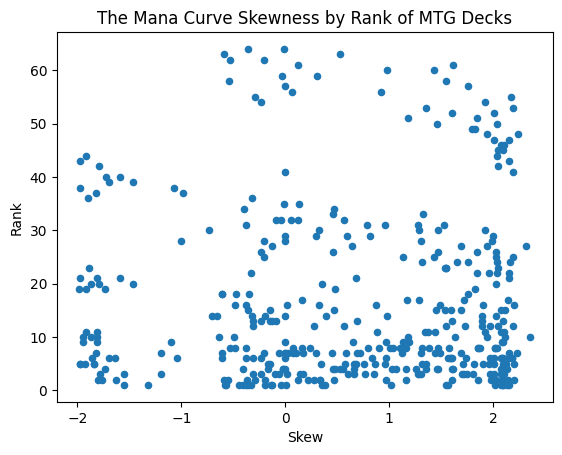

In [35]:
mc_skew_df.plot.scatter(x="Skew", y="Rank")
plt.title("The Mana Curve Skewness by Rank of MTG Decks")
plt.show()

According to the scatter plot, decks with a higher rank ("higher" as in closer to 1st) had a stronger positively skewed mana curve than decks that placed lower ("lower" as in closer to last). This indicates a potentially strong negative correlation between deck rank and mana curve skewness. Decks that have a mana curve with a stronger positive skew have more lower costing cards which means that they're able to play non-resource cards quicker and also end up with a higher rank.

## Ratio of Card Types

Analyzing the Mana Curve of a deck is only one way players get a feel for how their deck will play. They also look at the ratio of card types in their deck. Specifically, they look at the ratio between lands, creatures, and all other cards (typically referred to as just "spells"). We can construct our own version of this analysis using ratios!

First,  we'll need to link our cards to their decks by performing an inner join. This will keep only the common rows between the card and deck dataframes.

In [36]:
# link cards to their decks
ratio_linked_cards_df = pd.merge(cards_df, deck_cards_df, left_index=True, right_on="CardIdx", how="inner")

display(ratio_linked_cards_df.head())

,Name,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless,DeckIdx,CardIdx,Count
0,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,0,0,1
63,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,2,0,2
218,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,7,0,4
302,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,10,0,4
933,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,33,0,4


Now we can start compiling our ratios and their rank into the `ratios_df`. We'll group the larger dataframe by deck (i.e., "DeckIdx") and then for each deck we will calculate our ratios by getting the total number of cards of that type in the decka and dividing by the size of the deck. 

In [37]:
ratios_df = pd.DataFrame(columns=["DeckIdx", "Rank", "Land Ratio", "Creature Ratio", "Spells Ratio"])

for deck, deck_df in ratio_linked_cards_df.groupby("DeckIdx"):
    # land ratio
    land_ratio = len(deck_df[deck_df["Type"] == "Land"]) / len(deck_df)

    # creature ratio
    creature_ratio = len(deck_df[deck_df["Type"] == "Creature"]) / len(deck_df)

    # spells ratio
    spells_mask = (deck_df["Type"] != "Land") & (deck_df["Type"] != "Creature")
    spells_ratio = len(deck_df[spells_mask]) / len(deck_df)

    # save
    ratios_df.loc[len(ratios_df)] = [
        deck,
        decks_df.loc[deck, "Rank"],
        land_ratio,
        creature_ratio,
        spells_ratio
    ]
#

display(ratios_df.head())

,DeckIdx,Rank,Land Ratio,Creature Ratio,Spells Ratio
0,0.0,1.0,0.333333,0.133333,0.533333
1,1.0,2.0,0.272727,0.272727,0.454545
2,2.0,3.0,0.268293,0.219512,0.512195
3,3.0,1.0,0.275862,0.206897,0.517241
4,4.0,2.0,0.250000,0.142857,0.607143


It looks like we need to correct the datatypes so we can plot properly! The Deck index and Rank should be integers.

In [38]:
ratios_df[["DeckIdx", "Rank"]] = ratios_df[["DeckIdx", "Rank"]].astype(int)

display(ratios_df.head())

,DeckIdx,Rank,Land Ratio,Creature Ratio,Spells Ratio
0,0,1,0.333333,0.133333,0.533333
1,1,2,0.272727,0.272727,0.454545
2,2,3,0.268293,0.219512,0.512195
3,3,1,0.275862,0.206897,0.517241
4,4,2,0.250000,0.142857,0.607143


Now we can plot each of our card types. The independent variable, our card type, will go on the x-axis and the independent variable, the rank, will go on the y-axis so that we can visualize their correlation.

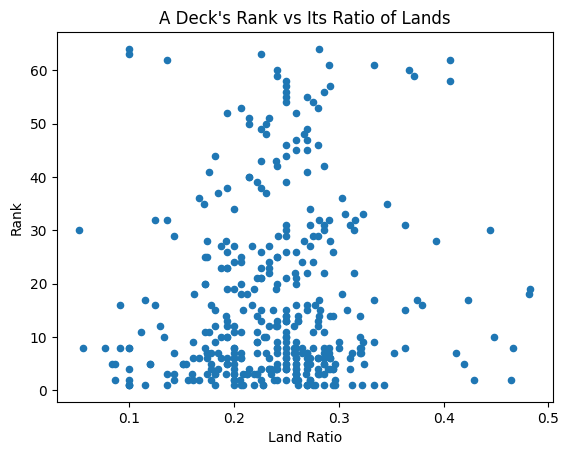

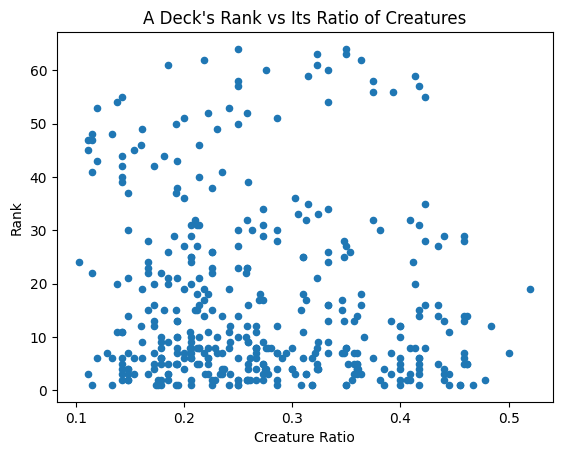

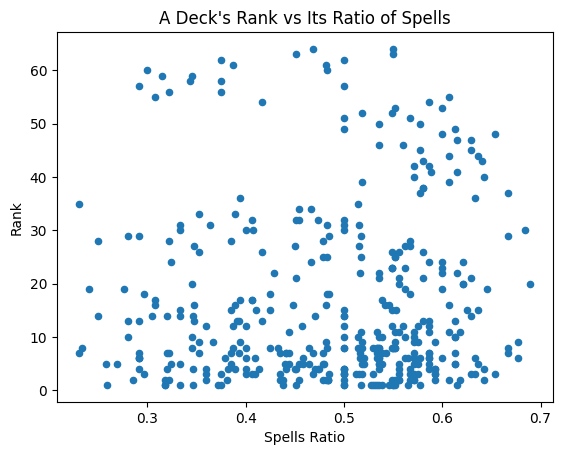

In [39]:
ratios_df.plot.scatter(x="Land Ratio", y="Rank", title="A Deck's Rank vs Its Ratio of Lands")
ratios_df.plot.scatter(x="Creature Ratio", y="Rank", title="A Deck's Rank vs Its Ratio of Creatures")
ratios_df.plot.scatter(x="Spells Ratio", y="Rank", title="A Deck's Rank vs Its Ratio of Spells")

plt.show()

According to the plots, a very clear correlation doesn't seem to be present among any of the three, but some relationship can be observed. For Land Ratio, it seems that top 10 decks dedicate 20-30% of it's size to just lands. For Creature Ratio, there is even less of a relationship but the plot does seem to be denser for the top 10 decks when creatures take up 10-20% of the deck's size. A deck's ratio of spells has decently clear bounds - somewhere between 30-70% of the decks size no matter the rank. This indicates that while card type ratio may not be a strong indicator of a deck's rank, there is some relationship there. 

## Distribution of Decks' Tournament Rankings

The end goal of this notebook is to train a model to predict a deck's winability based off the ranks we've collected, so it's important to visualize the distribution of our dataset over rank. We can do this by counting the frequency of unique values in the "Rank" column with pandas `.value_counts()`. Then, we can plot them on a histogram. 

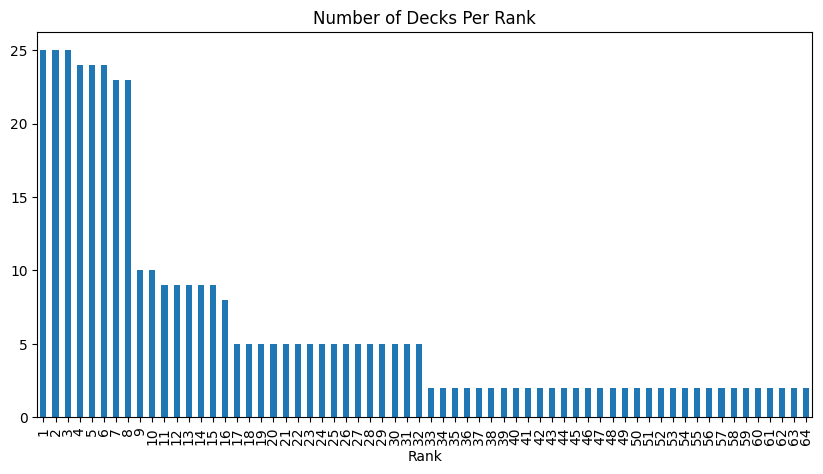

In [40]:
rank_freq = decks_df["Rank"].value_counts()         # counts frequency of unique values in "Rank"
rank_freq.plot.bar(title="Number of Decks Per Rank", figsize=(10, 5))       # bar plot 
plt.show()

The distribution of decks per rank is right skewed, meaning that there is drastically more deck data for ranks 1-8 than the rest! Let's take a closer look at the amount of data we have in the top 8 versus the rest of the ranks. 

In [41]:
print(f"Total Number of Samples in Top 8 Ranks:\t{rank_freq.loc[1:8].sum()}")
print(f"Total Number of Samples in Bottom 56 Ranks:\t{rank_freq.loc[9:].sum()}")

Total Number of Samples in Top 8 Ranks:	193
Total Number of Samples in Bottom 56 Ranks:	217


The two are pretty close! During model training, it might be best to consider classifying between groups of rankings instead of all 64 we have data for. This would allow us to maintain a good sample size for the amount of features we've collected and narrow down the amount of possibilities the model will need to consider and choose between.

# Modeling Deck Rankings for Tournaments

## A Logistic Regression Model for Classification

In the [Exploratory Data Analysis](#exploratory-data-analysis) section, many card features were aggregated into new deck features. To predict a deck's rank as an ordinal variable, we can leverage these new features along with some of the original ones to train a classification model. Specifically, we will use a deck's mana curve skewness, card type ratios, price, average amount of special abilities per card, mana type count, and the number of legendary cards. 

When it comes to modeling, we will treat predicting a winning deck as a classification problem. One popular model for classification is logistic regression. For this, we will be using Sci-kit Learn's [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) function to train a model to predict if a deck will make it into the tournament's top 8 ranks or not. The [Mana Curve Skewness](#mana-curve-skewness) and [Ratio of Card Types](#ratio-of-card-types) sections show that the top 8 have are tightly grouped together indicating a strong correlation with one another. Making the top 8 out of 64 is an impressive achievement, and at that stage in the standings, it could truly be anyone’s game which is most likely why we observe this relationship. Further, in the [Distribution of Decks' Tournament Rankings](#distribution-of-decks-tournament-rankings) section, the top 8 and bottom 56 have a roughly even split of the data. For these reasons, turning this into a binary classification problem seems reasonable! 

## Constructing Datasets for Training & Testing

This section constructs one dataframe that contains only the information we're planning on feeding to the model during training and testing. A great place to start is by copying our original decks dataframe and appending the new features directly onto it. We'll drop irrelevant columns later!

In [43]:
dataset_df = decks_df.copy()
display(dataset_df.head())

,Rank,Player,Name,Price,Link,TournamentIdx
0,1,Chloe Philip,Izzet Prowess,421.0,https://mtgtop8.com/event?e=82346&d=825866&f=ST,0
1,2,Benjamin Meyer,Azorius Aggro,562.0,https://mtgtop8.com/event?e=82346&d=825867&f=ST,0
2,3,Tjiang,Sultai Control,616.0,https://mtgtop8.com/event?e=82346&d=825868&f=ST,0
3,1,Alexandre Machado,Izzet Prowess,400.0,https://mtgtop8.com/event?e=82342&d=825839&f=ST,1
4,2,Alfredo Obregón,UW Control,540.0,https://mtgtop8.com/event?e=82342&d=825840&f=ST,1


As mentioned above, we'll be predicting if a deck is in the tournament's top 8 ranks or not. To get our labels for this we will create a "Top 8" column that will contain a `1` if its deck is rank 1-8 or a `0` if its rank is 9-64. We can do this by creating a boolean mask of the Rank column then casting it to integers. 

In [44]:
dataset_df["Top 8"] = (dataset_df["Rank"] <= 8).astype(int)

display(dataset_df.head())

,Rank,Player,Name,Price,Link,TournamentIdx,Top 8
0,1,Chloe Philip,Izzet Prowess,421.0,https://mtgtop8.com/event?e=82346&d=825866&f=ST,0,1
1,2,Benjamin Meyer,Azorius Aggro,562.0,https://mtgtop8.com/event?e=82346&d=825867&f=ST,0,1
2,3,Tjiang,Sultai Control,616.0,https://mtgtop8.com/event?e=82346&d=825868&f=ST,0,1
3,1,Alexandre Machado,Izzet Prowess,400.0,https://mtgtop8.com/event?e=82342&d=825839&f=ST,1,1
4,2,Alfredo Obregón,UW Control,540.0,https://mtgtop8.com/event?e=82342&d=825840&f=ST,1,1


### Compiling Features

Some deck features were already analyzed in the [EDA section](#exploratory-data-analysis), such as mana curve skewness and card type ratios. We can perform an inner join on the dataframes used to visualize these statistics with our dataset dataframe on the deck index column via pandas `.merge()` to save these values. 

In [45]:
# mana curve skewness
dataset_df = dataset_df.merge(
    mc_skew_df[["DeckIdx", "Skew"]],    # right table and its relevant columns
    left_index=True, right_on="DeckIdx", 
    how="inner"
)

# card type ratios
dataset_df = dataset_df.merge(
    ratios_df[["DeckIdx", "Land Ratio", "Creature Ratio", "Spells Ratio"]],     # right table and its relevant columns
    left_index=True, right_on="DeckIdx", 
    how="inner"
)

display(dataset_df.head())

,DeckIdx,Rank,Player,Name,Price,Link,TournamentIdx,Top 8,DeckIdx_x,Skew,DeckIdx_y,Land Ratio,Creature Ratio,Spells Ratio
0,0,1,Chloe Philip,Izzet Prowess,421.0,https://mtgtop8.com/event?e=82346&d=825866&f=ST,0,1,0,2.139458,0,0.333333,0.133333,0.533333
1,1,2,Benjamin Meyer,Azorius Aggro,562.0,https://mtgtop8.com/event?e=82346&d=825867&f=ST,0,1,1,0.4725,1,0.272727,0.272727,0.454545
2,2,3,Tjiang,Sultai Control,616.0,https://mtgtop8.com/event?e=82346&d=825868&f=ST,0,1,2,1.310032,2,0.268293,0.219512,0.512195
3,3,1,Alexandre Machado,Izzet Prowess,400.0,https://mtgtop8.com/event?e=82342&d=825839&f=ST,1,1,3,2.076984,3,0.275862,0.206897,0.517241
4,4,2,Alfredo Obregón,UW Control,540.0,https://mtgtop8.com/event?e=82342&d=825840&f=ST,1,1,4,0.966634,4,0.250000,0.142857,0.607143


Other deck features still need to be computed. We can start by inner joining our card dataframe with the linking dataframe, deck cards, via panda's `.merge()`. The final result is a merged dataframe that will let us group by deck and calculate aggregate card metrics.

In [46]:
merged_deck_cards = pd.merge(
    cards_df, 
    deck_cards_df, 
    left_index=True, right_on="CardIdx"
)
display(merged_deck_cards.head())

,Name,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless,DeckIdx,CardIdx,Count
0,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,0,0,1
63,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,2,0,2
218,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,7,0,4
302,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,10,0,4
933,Breeding Pool,Land,rare,False,NaN,NaN,NaN,0,1,0,0,1,0,33,0,4


The first aggregate feature is an average of the special abilities a deck's card possesses. We can group by the deck index, average the "Ability Count" column, and then save these results in the dataset dataframe at a new "Average Special Abilities" column. 

Another feature counts the number of legendary creatures in a deck by summing along the boolean "Legendary" column's values, treated as 0 for False and 1 for True by pandas. Legendaries are powerful creatures that can have a big impact on a game's outcome so tracking their presence is important. 

Lastly, the types of mana used in a deck and how much of it is another important factor to consider. A deck with too little mana cannot sustain itself while a deck with too much mana will not be able to defend. We can groupby the deck and then sum over each color's count to get the total amount of each kind of mana in the deck.  

In [47]:
# average amount of special abilities per card
dataset_df["Special Ability Count"] = merged_deck_cards.groupby("DeckIdx")["Ability Count"].mean()

# # number of legendary cards
dataset_df["Legendary Count"] = merged_deck_cards.groupby("DeckIdx")["Legendary"].sum()

# count amount of each mana type
mana_types = ["White", "Blue", "Black", "Green", "Colorless"]
dataset_df[mana_types] = merged_deck_cards.groupby("DeckIdx")[mana_types].sum()

display(dataset_df.head())

,DeckIdx,Rank,Player,Name,Price,Link,TournamentIdx,Top 8,DeckIdx_x,Skew,...,Land Ratio,Creature Ratio,Spells Ratio,Special Ability Count,Legendary Count,White,Blue,Black,Green,Colorless
0,0,1,Chloe Philip,Izzet Prowess,421.0,https://mtgtop8.com/event?e=82346&d=825866&f=ST,0,1,0,2.139458,...,0.333333,0.133333,0.533333,1.666667,1,0,22,0,3,15
1,1,2,Benjamin Meyer,Azorius Aggro,562.0,https://mtgtop8.com/event?e=82346&d=825867&f=ST,0,1,1,0.4725,...,0.272727,0.272727,0.454545,1.923077,5,27,17,0,0,27
2,2,3,Tjiang,Sultai Control,616.0,https://mtgtop8.com/event?e=82346&d=825868&f=ST,0,1,2,1.310032,...,0.268293,0.219512,0.512195,1.105263,1,3,22,24,8,44
3,3,1,Alexandre Machado,Izzet Prowess,400.0,https://mtgtop8.com/event?e=82342&d=825839&f=ST,1,1,3,2.076984,...,0.275862,0.206897,0.517241,1.8,1,0,25,4,2,20
4,4,2,Alfredo Obregón,UW Control,540.0,https://mtgtop8.com/event?e=82342&d=825840&f=ST,1,1,4,0.966634,...,0.250000,0.142857,0.607143,1.538462,2,10,21,4,0,23


Now that we have all of our features, we can clean up our dataset dataframe by dropping irrelevant columns and only keeping those we plan to train and test on!

In [48]:
dataset_df.drop(columns=["DeckIdx", "Player", "Name", "Link", "TournamentIdx", "DeckIdx_x", "DeckIdx_y", "Rank"], inplace=True)

display(dataset_df.head())

,Price,Top 8,Skew,Land Ratio,Creature Ratio,Spells Ratio,Special Ability Count,Legendary Count,White,Blue,Black,Green,Colorless
0,421.0,1,2.139458,0.333333,0.133333,0.533333,1.666667,1,0,22,0,3,15
1,562.0,1,0.4725,0.272727,0.272727,0.454545,1.923077,5,27,17,0,0,27
2,616.0,1,1.310032,0.268293,0.219512,0.512195,1.105263,1,3,22,24,8,44
3,400.0,1,2.076984,0.275862,0.206897,0.517241,1.8,1,0,25,4,2,20
4,540.0,1,0.966634,0.250000,0.142857,0.607143,1.538462,2,10,21,4,0,23


### Splitting Data

Now that our dataset has been constructed with the relevant features, we can split it into training and test sets. We will do hold-out cross validation by using Sci-kit Learn's [train-test-split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function to hold out 20% of the data for testing after training our model. We will also stratify by our labels so that each dataset gets the same amount of samples for both of the classes we're predicting. The first 5 examples in the training data are printed below!

**Note**: I'm passing the random seed 23 to the `train_test_split` function so that my results will be replicatable!

In [49]:
features = [        # this makes it easier to grab
    "Price", "Skew",
    "Land Ratio", "Creature Ratio", "Spells Ratio",     
    "Special Ability Count", "Legendary Count",
    "White", "Blue", "Black", "Green", "Colorless"
]

# split columns into X and y
X = dataset_df[features]
y = dataset_df["Top 8"]

# split train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y,
    random_state=23
)

display(X_train[:5], y_train[:5])

,Price,Skew,Land Ratio,Creature Ratio,Spells Ratio,Special Ability Count,Legendary Count,White,Blue,Black,Green,Colorless
404,302.0,1.439681,0.200000,0.266667,0.533333,1.666667,4,2,15,5,3,23
55,406.0,2.078518,0.241379,0.172414,0.586207,1.818182,1,1,21,4,1,21
377,748.0,-0.229979,0.200000,0.400000,0.400000,1.6,4,3,6,5,15,25
261,522.0,-0.35281,0.212121,0.363636,0.424242,2.277778,5,13,11,12,3,38
62,851.0,1.278751,0.235294,0.235294,0.529412,1.230769,4,4,16,5,7,27


404    0
55     1
377    1
261    0
62     1
Name: Top 8, dtype: int64

### Standardization

The last step before training on our data is standardization. The units for price, skew, and mana type count are drastically different and will influence our interpretation of the model's coefficients if not handled properly. Sci-kit Learn has a [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) that we can fit on our training data and then use to transform our training and test sets. 

**Note**: The test set must be transformed using the mean and standard deviation fitted on the training set. 

In [50]:
scaler = StandardScaler().fit(X_train)      # fit scaler with training data

# transform train and test set
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

display(X_train_sc[:5])

array([[-1.23695018,  0.67740767, -0.60161699, -0.04331294,  0.42490028,
         0.43187742,  0.83941696, -0.58460433,  0.37551381,  0.12707454,
        -0.51106515, -0.20868351],
       [-0.68305214,  1.17925562,  0.01212104, -1.01409503,  0.92673931,
         1.1069596 , -1.02091252, -0.7786835 ,  1.41637463, -0.10448351,
        -0.84598897, -0.49810505],
       [ 1.13842024, -0.63421721, -0.60161699,  1.32998855, -0.84060685,
         0.13484126,  0.83941696, -0.39052516, -1.18577741,  0.12707454,
         1.49847774,  0.08073802],
       [-0.0652428 , -0.73070902, -0.42183514,  0.95545178, -0.61051465,
         3.15470889,  1.45952679,  1.55026655, -0.3183934 ,  1.74798091,
        -0.51106515,  1.96197798],
       [ 1.68699233,  0.5509868 , -0.07813456, -0.3664427 ,  0.38767948,
        -1.51028208,  0.83941696, -0.19644599,  0.54899061,  0.12707454,
         0.15878248,  0.37015955]])

As you can see the first 5 samples from our training data look much closer in scale!

## Training & Evaluating Our Model 

### Training & Testing

Now that we have organized training and testing datasets that have been scaled appropriately we can start training our model! We'll configure our classifier to be Sci-kit Learn's `LogisticRegression()` and fit it on the scaled training data with the training labels. Then, we'll get a glimpse into the performance of our model by computing the accuracy with Sci-kit Learn's `.score()` for the training and test sets.  

In [51]:
clf = LogisticRegression().fit(X_train_sc, y_train)     # fit model

# compute accuracy
train_accuracy = clf.score(X_train_sc, y_train)
test_accuracy = clf.score(X_test_sc, y_test)

print(f"Training Accuracy:\t{train_accuracy*100:.2f}%")
print(f"Testing Accuracy:\t{test_accuracy*100:.2f}%")

Training Accuracy:	59.15%
Testing Accuracy:	51.22%


Looks like we're doing slightly better than a random coin flip! Our testing accuracy is worse than our training accuracy, though, so it looks like we might be overfitting, as well. 

To combat the overfitting, we can apply regularization but this will require performing a grid search to find the optimal `C` value that controls the regularization strength. According to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), `C=1.0` by default and we'll need to go much smaller to apply stronger regularization. We'll select from three (very small) values: `[0.01, 0.05, 0.1]` using 10-fold cross validation. 

In [52]:
grid = {'C': [0.1, 0.5, 0.8]}      # C options

# grid search
grid_search = GridSearchCV(LogisticRegression(), grid, cv=10)
grid_search.fit(X_train_sc, y_train)

# compute accuracy
gs_train_accuracy = grid_search.score(X_train_sc, y_train)
gs_test_accuracy = grid_search.score(X_test_sc, y_test)

print(f"Training Accuracy with C={grid_search.best_params_['C']}:\t{gs_train_accuracy*100:.2f}")
print(f"Test Accuracy with C={grid_search.best_params_['C']}:\t{gs_test_accuracy*100:.2f}")

Training Accuracy with C=0.1:	60.06
Test Accuracy with C=0.1:	53.66


That's a little better! When `C=0.1`, our training accuracy increases a touch but our testing accuracy increases by almost 2 points. We'll use this grid search fitted model for further analysis of our performance.  

### Evaluating

With a trained model, we can observe where it's making mistakes (i.e., confusing it's predicted and ground truth labels) with a confusion matrix! Sci-kit Learn has a `confusion_matrix` function that takes our ground truth labels and our predicted labels then uses the `ConfusionMatrixDisplay` to plot it. Additionally, we can calulate the precision and recall using Sci-kit Learn's `recall_score()` and `precision_score()`. We'll pass the functions our ground truth and predicted labels.

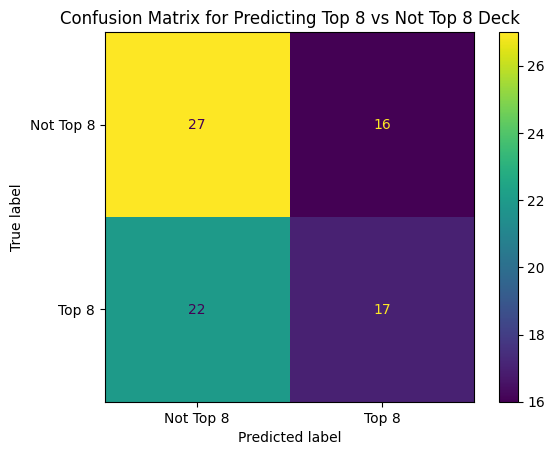

Recall:	0.44
Precision:	0.52


In [53]:
conf_mat = confusion_matrix(
    y_test,     # ground truth labels
    grid_search.predict(X_test_sc)      # predicted labels
)

# plotting matrix
ConfusionMatrixDisplay(confusion_matrix=conf_mat).plot()
plt.title("Confusion Matrix for Predicting Top 8 vs Not Top 8 Deck")
plt.xticks([0, 1], ["Not Top 8", "Top 8"])
plt.yticks([0, 1], ["Not Top 8", "Top 8"])
plt.show()

# precision & recall
r = recall_score(
    y_test,     # ground truth labels
    grid_search.predict(X_test_sc)      # predicted labels
)
p = precision_score(
    y_test,     # ground truth labels
    grid_search.predict(X_test_sc)      # predicted labels
)
print(f"Recall:\t{r:.2f}")
print(f"Precision:\t{p:.2f}")

The confusion matrix plot above shows that the model does a slightly better job at predicting true negatives than true positives. This can also be seen in the precision and recall scores. The model earns a higher precision score meaning it is more selective about which decks it will grant a "top 8" classification to. 

Deck tournament rankings are very noisy and can shift overtime, so having a more selective model that predicts positive cases when it's more confident is a good fit for our use case!  

## Which features have the biggest impact on a deck's rank in competitive tournaments?

Now that we have a model trained (that is doing at least a little better than random guessing) we can start analyzing which features it found to have the biggest impact on predicting a deck's success!

Sci-kit Learn's grid search method has a `.best_estimator_` attribute we can access that contains the learned coefficients in a `.coef_` variable. These coefficients are stored in a list and are in the same order as our original features. Using this, we can pair them together in a pandas Series by passing our list of coefficients and then index the series by our features list we created earlier. 

In [54]:
coeffs = grid_search.best_estimator_.coef_[0]       # get coefficients

feature_s = pd.Series(coeffs, index=features)      # match with features

display(feature_s)

Price                   -0.073142
Skew                     0.177572
Land Ratio              -0.201646
Creature Ratio           0.088661
Spells Ratio             0.047336
Special Ability Count   -0.160001
Legendary Count          0.011785
White                    0.105011
Blue                    -0.190498
Black                    0.029113
Green                    0.121094
Colorless                0.007842
dtype: float64

The features that have the largest coefficients by magnitude have the biggest impact on the prediction of our model. We can find the top 3 features by taking the absolute value of our series (since we're only concerned with magnitude), finding the 3 largest, then getting their index. We'll print our most impactful features along with their true values. 

In [55]:
ft_idx = feature_s.abs().nlargest(3).index

print(f"Top 3 Most Impactful Deck Features:\n{feature_s[ft_idx]}")

Top 3 Most Impactful Deck Features:
Land Ratio   -0.201646
Blue         -0.190498
Skew          0.177572
dtype: float64


For standard tournaments, our most impactful feature is the ratio of lands in a deck. Shockingly, it looks like the more lands you have the worse your chances are for getting into the top 8 at standard tournaments! This is quite suprising considering that lands are the only way to actually play the cards you have stored in your deck, but too many may interfere with playing cards that can deal damage to your opponent. I guess too much of a good thing can be a bad thing!

Another (somewhat) shocking revelation from our data is that the amount of blue lands, or mana, has an almost as negative impact on making top 8 as having too many lands. This mana resource is best known for its "removal". Many cards that require blue mana to be played are typically used to remove cards from the game that an opponent has already played and is actively still using. The community really values their removal so this having such a negative impact is also decently suprising. Like the lands above, it could be that too much removal simply interferes with making progress against your opponent. 

Skew refers to the mana curve skewness that we derived earlier. The model learned that larger, more positive skew values are better. This means that decks with a long right tail, i.e., contain more cards that cost less, have a better chance at making top 8 in standard tournaments. This coefficient's value is not as suprising since lower cost cards can be played sooner and possibly give you an edge over your opponent!

# Conclusion & Future Work

In conclusion, when constructing a deck that will rank highly in standard tournaments, competitors should be mindful of how many interaction cards they have included. Too many resource or removal cards have a strong negative impact on a competitors ability to win a game, most likely due to having fewer cards that can deal damage to an opponent. Considering a deck's mana curve, however, is highly encouraged! A deck played in standard tournaments should have mostly have cards with a very cheap in-game cost. When putting this all together, top ranking decks in standard tournaments consist mostly of direct interaction cards that deal damage to an opponent and do not require many resource cards to play. 

This analysis is limited by its observance of *only* individual decks. Future analyses into top ranking decks should examine interactions between decks and factor in a player's skill.

In [1]:
!jupyter nbconvert --to html /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Final.ipynb

[NbConvertApp] Converting notebook /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 745718 bytes to /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Final.html
